# RMSD of AFQMC, CCSD(T), and CCSDT vs CCSDT(Q) — Atomization Energies — VTZ(f,p)

Reference method is **CCSDT(Q)**. We compute the root-mean-square deviation of
AFQMC, CCSD(T), and CCSDT **atomization energies** relative to CCSDT(Q), over
the molecules for which both the predicted value and a CCSDT(Q) value are
available.

**Atomization energy:**
$$E_{\rm at} = \sum_i n_i\, E(\text{atom}_i) - E(\text{molecule}) \quad (E_h)$$

**AFQMC stochastic uncertainty propagation:**
$$\sigma(E_{\rm at}) = \sqrt{\sigma_{\rm mol}^2 + \sum_i n_i^2\,\sigma_{\rm atom_i}^2}$$

Data source (VTZ(f,p) basis) — all energies live in a single file,
`energy_vtzfp.dat`, with the molecule rows first and the atom rows in a second
block at the bottom (header starting with `Atom`). Columns:
`Molecule | E_HF | E_CCSD | E_UHF-UCCSD(T) | E_UHF-UCCSDT | E_CCSDT(Q) | E_AFQMC | E_AFQMC_err`
- `E_UHF-UCCSD(T)`  -> CCSD(T)
- `E_UHF-UCCSDT`    -> CCSDT
- `E_CCSDT(Q)`      -> CCSDT(Q)  (reference)

Molecule shell type (closed/open) is taken from which `w4_17_xyz/` subdirectory
holds the geometry.

Uses numpy + matplotlib (env: `pyscf_afqmc`).

In [1]:
import os
import numpy as np
from collections import Counter

HARTREE2KCAL = 627.5094740631

BASE   = '/home/yichi/research/w4_17/w4-17_all'
XYZ_CS = os.path.join(BASE, 'w4_17_xyz', 'closed_shell')
XYZ_OS = os.path.join(BASE, 'w4_17_xyz', 'open_shell')

# the 11 elements present in the dataset; rows with these names are atoms
ATOMS = {'al', 'b', 'c', 'cl', 'f', 'h', 'n', 'o', 'p', 's', 'si'}


def to_float(tok):
    '''Parse a token to float; 'N/A'/non-numeric -> NaN.'''
    try:
        return float(tok)
    except ValueError:
        return np.nan


def skip_line(line):
    '''Return True for blank, comment, separator, or header lines.'''
    s = line.strip()
    return (not s or s.startswith('#') or s.startswith('-')
            or s.startswith('Molecule') or s.startswith('Atom'))

In [2]:
# --- Load every energy from the single combined file energy_vtzfp.dat ---
# cols: Molecule  E_HF  E_CCSD  E_UHF-UCCSD(T)  E_UHF-UCCSDT  E_CCSDT(Q)  E_AFQMC  E_AFQMC_err
# Molecule rows (compounds) and atom rows (single elements) share this layout;
# atoms are identified by name membership in ATOMS.
mol_afqmc, mol_afqmc_err, mol_ref = {}, {}, {}
atom_afqmc, atom_afqmc_err, atom_ref = {}, {}, {}

with open('energy_vtzfp.dat') as f:
    for line in f:
        if skip_line(line):
            continue
        p = line.split()
        name = p[0]
        cc = {'CCSD(T)': to_float(p[3]), 'CCSDT': to_float(p[4]), 'CCSDT(Q)': to_float(p[5])}
        e_afqmc, e_afqmc_err = to_float(p[6]), to_float(p[7])
        if name.lower() in ATOMS:
            atom_afqmc[name.lower()]     = e_afqmc
            atom_afqmc_err[name.lower()] = e_afqmc_err
            atom_ref[name.lower()]       = cc
        else:
            mol_afqmc[name]     = e_afqmc
            mol_afqmc_err[name] = e_afqmc_err
            mol_ref[name]       = cc

print('molecule entries:', len(mol_afqmc), ' atom entries:', len(atom_afqmc))
print('atoms:', sorted(atom_afqmc))
print('molecules missing CCSDT(Q):',
      [n for n, d in mol_ref.items() if not np.isfinite(d['CCSDT(Q)'])])

molecule entries: 200  atom entries: 11
atoms: ['al', 'b', 'c', 'cl', 'f', 'h', 'n', 'o', 'p', 's', 'si']
molecules missing CCSDT(Q): ['c2cl6', 'c2f6']


In [3]:
# --- Assign molecule shell type from the xyz subdirectory ---
open_set = {f[:-4] for f in os.listdir(XYZ_OS) if f.endswith('.xyz')}
shell = {m: ('open' if m in open_set else 'closed') for m in mol_afqmc}
print('closed-shell:', sum(s == 'closed' for s in shell.values()),
      ' open-shell:', sum(s == 'open' for s in shell.values()))

closed-shell: 160  open-shell: 40


In [4]:
# --- Parse XYZ geometries -> atomic compositions ---
def parse_xyz(path):
    '''Return Counter of element symbols (lowercase) from an XYZ file.'''
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[0].strip())
    comp = Counter()
    for line in lines[2:2 + n_atoms]:
        comp[line.split()[0].lower()] += 1
    return comp


compositions = {}
for mol in mol_afqmc:
    xyz_dir = XYZ_OS if shell[mol] == 'open' else XYZ_CS
    compositions[mol] = parse_xyz(os.path.join(xyz_dir, f'{mol}.xyz'))

all_elem = set(e for comp in compositions.values() for e in comp)
print('unique elements:', sorted(all_elem))
print('missing from AFQMC atom table:', all_elem - set(atom_afqmc) or 'None')
print('missing from CC atom table:   ', all_elem - set(atom_ref)   or 'None')

unique elements: ['al', 'b', 'c', 'cl', 'f', 'h', 'n', 'o', 'p', 's', 'si']
missing from AFQMC atom table: None
missing from CC atom table:    None


In [5]:
# --- Compute atomization energies (Eh) ---
# Same dict layout as the molecular-energy notebook so the RMSD / bar-chart
# cells below carry over unchanged:
#   afqmc[name]      -> AFQMC atomization energy (Eh)
#   afqmc_err[name]  -> propagated AFQMC stochastic error (Eh)
#   ref[name]        -> {'CCSD(T)', 'CCSDT', 'CCSDT(Q)'} atomization energies (Eh)
afqmc, afqmc_err, ref = {}, {}, {}
for mol, comp in compositions.items():
    # AFQMC
    e_atoms = sum(n * atom_afqmc[e] for e, n in comp.items())
    afqmc[mol] = e_atoms - mol_afqmc[mol]
    sig_atoms = np.sqrt(sum((n * atom_afqmc_err[e])**2 for e, n in comp.items()))
    afqmc_err[mol] = np.sqrt(mol_afqmc_err[mol]**2 + sig_atoms**2)
    # CC reference methods
    ref[mol] = {}
    for m in ('CCSD(T)', 'CCSDT', 'CCSDT(Q)'):
        e_atoms_cc = sum(n * atom_ref[e][m] for e, n in comp.items())
        ref[mol][m] = e_atoms_cc - mol_ref[mol][m]

print('computed atomization energies for', len(afqmc), 'molecules')
ae_q = np.array([ref[m]['CCSDT(Q)'] for m in afqmc])
ae_q = ae_q[np.isfinite(ae_q)] * HARTREE2KCAL
print(f'AE_CCSDT(Q) range: {ae_q.min():.1f} - {ae_q.max():.1f} kcal/mol '
      f'({len(ae_q)} molecules with a CCSDT(Q) reference)')

computed atomization energies for 200 molecules
AE_CCSDT(Q) range: 35.4 - 1552.7 kcal/mol (198 molecules with a CCSDT(Q) reference)


In [6]:
# --- Names present in each table (informational) ---
only_ref   = sorted(set(ref) - set(afqmc))
only_afqmc = sorted(set(afqmc) - set(ref))
print('in reference but not AFQMC:', only_ref)
print('in AFQMC but not reference:', only_afqmc)

in reference but not AFQMC: []
in AFQMC but not reference: []


In [7]:
# --- Compute RMSD vs CCSDT(Q) ---
def rmsd_stats(get_pred, names=None, with_err=False):
    '''RMSD of predicted vs CCSDT(Q) atomization energies over molecules where
    both are finite.

    Returns (rmsd, unc, N) in Eh. If `with_err`, the AFQMC stochastic errors
    are propagated into `unc` via
        sigma_RMSD = sqrt(sum_i d_i^2 * sigma_i^2) / (N * RMSD);
    otherwise unc = 0 (CCSD(T)/CCSDT are deterministic).
    `names` optionally restricts to a subset (default: all reference molecules).
    '''
    if names is None:
        names = ref.keys()
    diffs, errs = [], []
    for name in names:
        d = ref.get(name)
        if d is None:
            continue
        eq = d['CCSDT(Q)']
        pred = get_pred(name, d)
        if pred is None or not (np.isfinite(eq) and np.isfinite(pred)):
            continue
        diffs.append(pred - eq)
        errs.append(afqmc_err.get(name, 0.0) if with_err else 0.0)
    diffs, errs = np.array(diffs), np.array(errs)
    r = np.sqrt(np.mean(diffs**2))
    n = len(diffs)
    unc = np.sqrt(np.sum(diffs**2 * errs**2)) / (n * r) if r > 0 else 0.0
    return r, unc, n


# method label -> (predictor, propagate stochastic error?)
methods = {
    'AFQMC':   (lambda name, d: afqmc.get(name), True),
    'CCSD(T)': (lambda name, d: d['CCSD(T)'],    False),
    'CCSDT':   (lambda name, d: d['CCSDT'],      False),
}

print('RMSD vs CCSDT(Q) (reference) -- atomization energies')
print('=' * 70)
for label, (fn, with_err) in methods.items():
    r, unc, n = rmsd_stats(fn, with_err=with_err)
    pm = f' +/- {unc*1e3:6.4f}' if with_err else ' ' * 13
    print(f'{label:>8s}  (N={n:3d})   {r*1e3:8.4f}{pm} mEh   '
          f'{r*HARTREE2KCAL:8.4f} kcal/mol')

RMSD vs CCSDT(Q) (reference) -- atomization energies
   AFQMC  (N=198)     1.2873 +/- 0.0316 mEh     0.8078 kcal/mol
 CCSD(T)  (N=198)     1.3184              mEh     0.8273 kcal/mol
   CCSDT  (N=198)     2.1397              mEh     1.3427 kcal/mol


## Multireference subset: RMSD vs CCSDT(Q)

The W4-17 dataset flags 17 molecules with significant nondynamical
(multireference) character. We repeat the RMSD analysis restricted to this
subset, again using **CCSDT(Q)** as the reference. The list of names is read
from `../../w4_17_xyz/multireference_mols.txt`.

In [8]:
# --- Load the multireference molecule list ---
# File format: comma-separated names (an optional leading "<idx>\t" is ignored).
mr_mols = []
with open('../../w4_17_xyz/multireference_mols.txt') as f:
    for line in f:
        parts = line.split('\t', 1)
        body = parts[1] if len(parts) > 1 else parts[0]
        for tok in body.split(','):
            name = tok.strip()
            if name:
                mr_mols.append(name)
mr_set = set(mr_mols)
print(f'multireference molecules ({len(mr_set)}):', sorted(mr_set))
print('MR names missing from reference data:', sorted(mr_set - set(ref)))

multireference molecules (17): ['b2', 'bn', 'c2', 'cl2o', 'clf3', 'clf5', 'clo3', 'cloo', 'cloocl', 'f2o', 'fo2', 'foof', 'o3', 'oclo', 'of', 's3', 's4-c2v']
MR names missing from reference data: []


In [9]:
# --- Compute RMSD vs CCSDT(Q) over the multireference subset only ---
print('RMSD vs CCSDT(Q) -- multireference subset (atomization energies)')
print('=' * 70)
for label, (fn, with_err) in methods.items():
    r, unc, n = rmsd_stats(fn, names=mr_set, with_err=with_err)
    pm = f' +/- {unc*1e3:6.4f}' if with_err else ' ' * 13
    print(f'{label:>8s}  (N={n:3d})   {r*1e3:8.4f}{pm} mEh   '
          f'{r*HARTREE2KCAL:8.4f} kcal/mol')

RMSD vs CCSDT(Q) -- multireference subset (atomization energies)
   AFQMC  (N= 17)     2.6033 +/- 0.0876 mEh     1.6336 kcal/mol
 CCSD(T)  (N= 17)     3.3465              mEh     2.1000 kcal/mol
   CCSDT  (N= 17)     4.4605              mEh     2.7990 kcal/mol


## Method comparison: MAE and RMSE bar chart

Grouped bar chart of the atomization-energy deviation `E_method - E[CCSDT(Q)]`
summarised as **MAE** and **RMSE** (kcal/mol). Bars are grouped by molecule set
on the x-axis (all, closed-shell, open-shell, multireference) with one bar per
method (AFQMC, CCSD(T), CCSDT). The dashed grey line marks **chemical accuracy
(1 kcal/mol)**. All sets use the molecules that have both an AFQMC value and a
finite CCSDT(Q) reference, so the three methods share an identical sample
within each group.

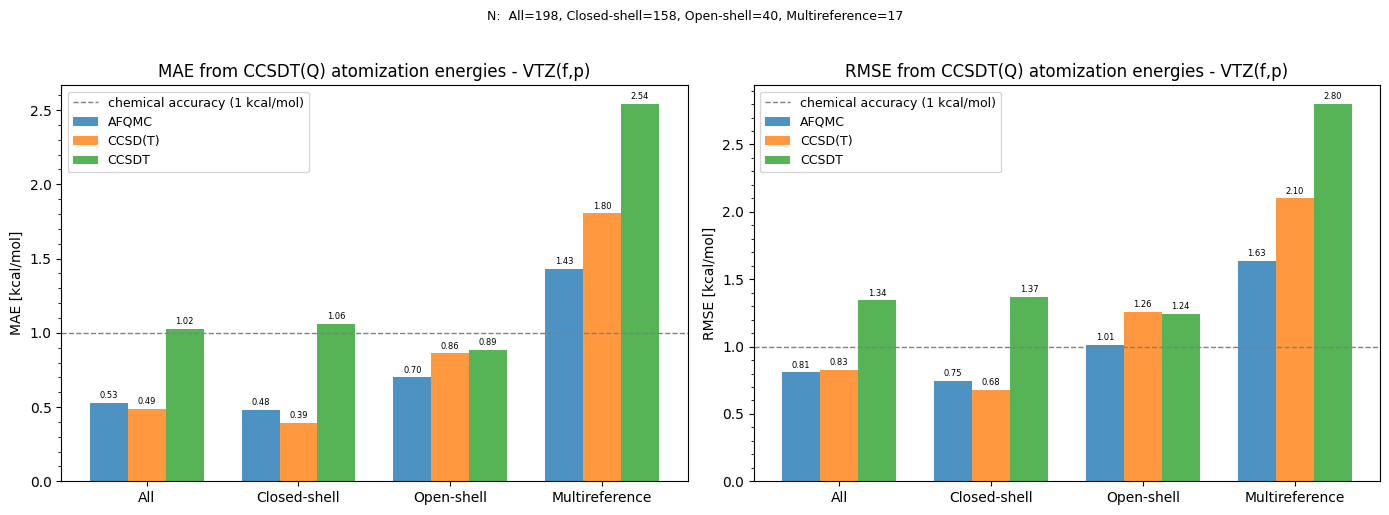

Saved atomization_method_comparison_vtzfp.png


In [10]:
# --- Method comparison: MAE and RMSE bar chart (vs CCSDT(Q)) ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def has_ref(name):
    d = ref.get(name)
    return d is not None and np.isfinite(d['CCSDT(Q)'])


# common molecule set: AFQMC value + finite CCSDT(Q) reference
mol_names = sorted(m for m in afqmc if has_ref(m))

# per-molecule atomization deviations from CCSDT(Q), in kcal/mol
dAFQMC  = np.array([afqmc[m]          - ref[m]['CCSDT(Q)'] for m in mol_names]) * HARTREE2KCAL
dCCSD_T = np.array([ref[m]['CCSD(T)'] - ref[m]['CCSDT(Q)'] for m in mol_names]) * HARTREE2KCAL
dCCSDT  = np.array([ref[m]['CCSDT']   - ref[m]['CCSDT(Q)'] for m in mol_names]) * HARTREE2KCAL

cs_mask = np.array([shell.get(m) == 'closed' for m in mol_names])
os_mask = np.array([shell.get(m) == 'open' for m in mol_names])
mr_mask = np.array([m in mr_set for m in mol_names])

method_labels = ['AFQMC', 'CCSD(T)', 'CCSDT']
deltas = [dAFQMC, dCCSD_T, dCCSDT]
method_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

subset_labels = ['All', 'Closed-shell', 'Open-shell', 'Multireference']
masks = [np.ones(len(mol_names), dtype=bool), cs_mask, os_mask, mr_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, stat_label in enumerate(['MAE', 'RMSE']):
    ax = axes[ax_idx]
    w = 0.25
    x_base = np.arange(len(subset_labels))

    for j, (mlabel, delta, mcolor) in enumerate(zip(method_labels, deltas, method_colors)):
        vals = []
        for mask in masks:
            d = delta[mask]
            vals.append(np.abs(d).mean() if stat_label == 'MAE'
                        else np.sqrt((d**2).mean()))
        offset = (j - 1) * w
        bars = ax.bar(x_base + offset, vals, width=w, color=mcolor, alpha=0.8, label=mlabel)
        ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)

    # chemical accuracy reference line at 1 kcal/mol
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=1.0,
               label='chemical accuracy (1 kcal/mol)')

    ax.set_xticks(x_base)
    ax.set_xticklabels(subset_labels)
    ax.set_ylabel(f'{stat_label} [kcal/mol]')
    ax.set_title(f'{stat_label} from CCSDT(Q) atomization energies - VTZ(f,p)')
    ax.legend(fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

counts = ', '.join(f'{lbl}={int(m.sum())}' for lbl, m in zip(subset_labels, masks))
fig.suptitle(f'N:  {counts}', y=1.02, fontsize=9)

plt.tight_layout()
plt.savefig('atomization_method_comparison_vtzfp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved atomization_method_comparison_vtzfp.png')

## Same-molecule comparison with the DZ basis (shared set)

To compare TZ and DZ results on an identical footing, this repeats the MAE/RMSE
bar chart restricted to the molecules that **also have a CCSDT(Q) reference in
the VDZ(d,s) data** (`../vdzds/mol_ref_vdzds.dat`). `c2cl6` and `c2f6` lack a TZ
CCSDT(Q) value and so are already absent here; the shared set is the 198
molecules common to both bases, matching the DZ notebook exactly.

shared TZ/DZ molecules: 198   (dropped, no DZ CCSDT(Q): [])


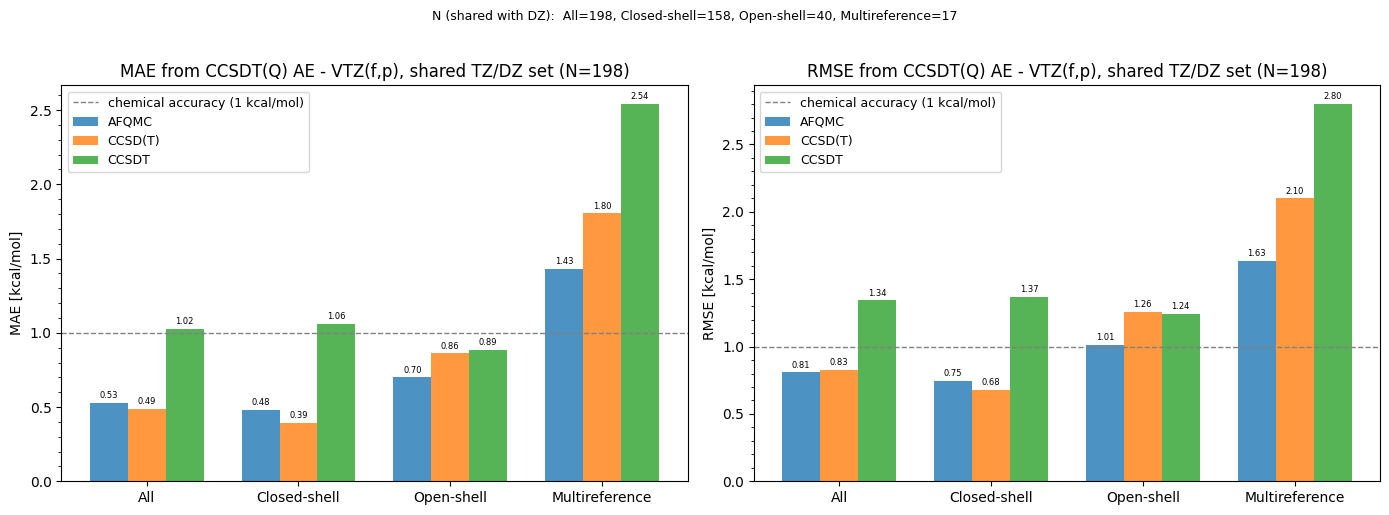

Saved atomization_method_comparison_vtzfp_sharedDZ.png


In [11]:
# --- Same comparison restricted to the molecules shared with the DZ set ---
# Keep only molecules that ALSO have a finite CCSDT(Q) reference in the VDZ(d,s)
# data, so the TZ and DZ bar charts span an identical molecule set.
dz_finite = set()
with open('../vdzds/mol_ref_vdzds.dat') as f:
    for line in f:
        if skip_line(line):
            continue
        p = line.split()
        if np.isfinite(to_float(p[5])):
            dz_finite.add(p[0])

common  = sorted(m for m in afqmc if has_ref(m) and m in dz_finite)
dropped = sorted(m for m in afqmc if has_ref(m) and m not in dz_finite)
print(f'shared TZ/DZ molecules: {len(common)}   (dropped, no DZ CCSDT(Q): {dropped})')

# atomization deviations from CCSDT(Q) in kcal/mol over the shared set
dAFQMC_c  = np.array([afqmc[m]          - ref[m]['CCSDT(Q)'] for m in common]) * HARTREE2KCAL
dCCSD_T_c = np.array([ref[m]['CCSD(T)'] - ref[m]['CCSDT(Q)'] for m in common]) * HARTREE2KCAL
dCCSDT_c  = np.array([ref[m]['CCSDT']   - ref[m]['CCSDT(Q)'] for m in common]) * HARTREE2KCAL
deltas_c = [dAFQMC_c, dCCSD_T_c, dCCSDT_c]

cs_c = np.array([shell.get(m) == 'closed' for m in common])
os_c = np.array([shell.get(m) == 'open' for m in common])
mr_c = np.array([m in mr_set for m in common])
masks_c = [np.ones(len(common), dtype=bool), cs_c, os_c, mr_c]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, stat_label in enumerate(['MAE', 'RMSE']):
    ax = axes[ax_idx]
    w = 0.25
    x_base = np.arange(len(subset_labels))
    for j, (mlabel, delta, mcolor) in enumerate(zip(method_labels, deltas_c, method_colors)):
        vals = []
        for mask in masks_c:
            d = delta[mask]
            vals.append(np.abs(d).mean() if stat_label == 'MAE'
                        else np.sqrt((d**2).mean()))
        bars = ax.bar(x_base + (j - 1) * w, vals, width=w, color=mcolor, alpha=0.8, label=mlabel)
        ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=1.0,
               label='chemical accuracy (1 kcal/mol)')
    ax.set_xticks(x_base)
    ax.set_xticklabels(subset_labels)
    ax.set_ylabel(f'{stat_label} [kcal/mol]')
    ax.set_title(f'{stat_label} from CCSDT(Q) AE - VTZ(f,p), shared TZ/DZ set (N={len(common)})')
    ax.legend(fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

counts = ', '.join(f'{lbl}={int(m.sum())}' for lbl, m in zip(subset_labels, masks_c))
fig.suptitle(f'N (shared with DZ):  {counts}', y=1.02, fontsize=9)
plt.tight_layout()
plt.savefig('atomization_method_comparison_vtzfp_sharedDZ.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved atomization_method_comparison_vtzfp_sharedDZ.png')

## Molecular total-energy deviations from CCSDT(Q)

The bar charts above compare **atomization** energies. Here we instead look at
the raw **molecular total energies** `E(molecule)` directly against the CCSDT(Q)
reference (no atomic contributions, no atomization step), over the 198 molecules
that carry a finite CCSDT(Q) value. This isolates how well each method
reproduces the reference *molecular* energy, summarised as **MAE** and **RMSE**
(kcal/mol) per molecule set.

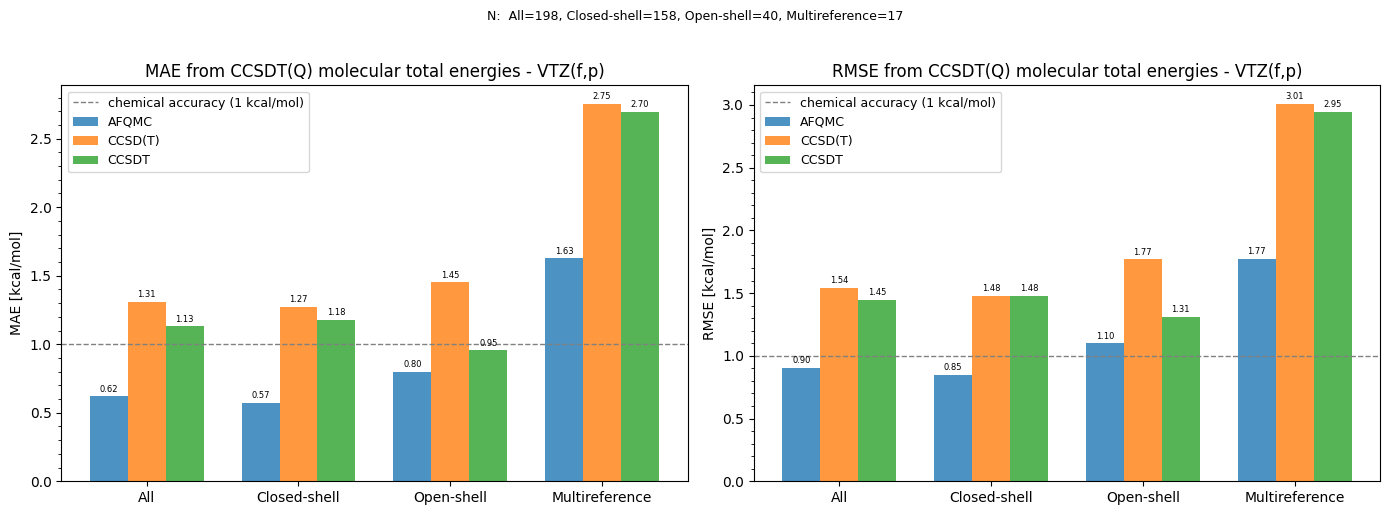

Saved molecular_energy_comparison_vtzfp.png

Molecular total-energy deviation from CCSDT(Q) -- all 198 molecules
   AFQMC   MAE= 0.6191   RMSE= 0.9023 kcal/mol
 CCSD(T)   MAE= 1.3095   RMSE= 1.5417 kcal/mol
   CCSDT   MAE= 1.1307   RMSE= 1.4467 kcal/mol


In [12]:
# --- Molecular total-energy deviations from CCSDT(Q) (198 molecules) ---
# molecules with a finite CCSDT(Q) total-energy reference
mol_names_E = sorted(m for m in mol_afqmc
                     if np.isfinite(mol_ref[m]['CCSDT(Q)']))

# per-molecule total-energy deviations from CCSDT(Q), in kcal/mol
dAFQMC_E  = np.array([mol_afqmc[m]          - mol_ref[m]['CCSDT(Q)'] for m in mol_names_E]) * HARTREE2KCAL
dCCSD_T_E = np.array([mol_ref[m]['CCSD(T)'] - mol_ref[m]['CCSDT(Q)'] for m in mol_names_E]) * HARTREE2KCAL
dCCSDT_E  = np.array([mol_ref[m]['CCSDT']   - mol_ref[m]['CCSDT(Q)'] for m in mol_names_E]) * HARTREE2KCAL
deltas_E = [dAFQMC_E, dCCSD_T_E, dCCSDT_E]

cs_E = np.array([shell.get(m) == 'closed' for m in mol_names_E])
os_E = np.array([shell.get(m) == 'open' for m in mol_names_E])
mr_E = np.array([m in mr_set for m in mol_names_E])
masks_E = [np.ones(len(mol_names_E), dtype=bool), cs_E, os_E, mr_E]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_idx, stat_label in enumerate(['MAE', 'RMSE']):
    ax = axes[ax_idx]
    w = 0.25
    x_base = np.arange(len(subset_labels))
    for j, (mlabel, delta, mcolor) in enumerate(zip(method_labels, deltas_E, method_colors)):
        vals = []
        for mask in masks_E:
            d = delta[mask]
            vals.append(np.abs(d).mean() if stat_label == 'MAE'
                        else np.sqrt((d**2).mean()))
        bars = ax.bar(x_base + (j - 1) * w, vals, width=w, color=mcolor, alpha=0.8, label=mlabel)
        ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=1.0,
               label='chemical accuracy (1 kcal/mol)')
    ax.set_xticks(x_base)
    ax.set_xticklabels(subset_labels)
    ax.set_ylabel(f'{stat_label} [kcal/mol]')
    ax.set_title(f'{stat_label} from CCSDT(Q) molecular total energies - VTZ(f,p)')
    ax.legend(fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

counts = ', '.join(f'{lbl}={int(m.sum())}' for lbl, m in zip(subset_labels, masks_E))
fig.suptitle(f'N:  {counts}', y=1.02, fontsize=9)
plt.tight_layout()
plt.savefig('molecular_energy_comparison_vtzfp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved molecular_energy_comparison_vtzfp.png')

# print the RMSD/MAE numbers for the All set
print()
print(f'Molecular total-energy deviation from CCSDT(Q) -- all {len(mol_names_E)} molecules')
print('=' * 70)
for mlabel, delta in zip(method_labels, deltas_E):
    print(f'{mlabel:>8s}   MAE={np.abs(delta).mean():7.4f}   '
          f'RMSE={np.sqrt((delta**2).mean()):7.4f} kcal/mol')

## Atomic total-energy deviations from CCSDT(Q)

The atomization energies are built from the 11 atomic total energies, so it is
worth checking how each method reproduces the **atoms** themselves. The atoms
do not split into closed/open/multireference sets, so the **left panel** shows
the signed per-atom deviation `E_method - E[CCSDT(Q)]` (kcal/mol) for all 11
atoms, and the **right panel** summarises them as **MAE** and **RMSE** over the
whole set.

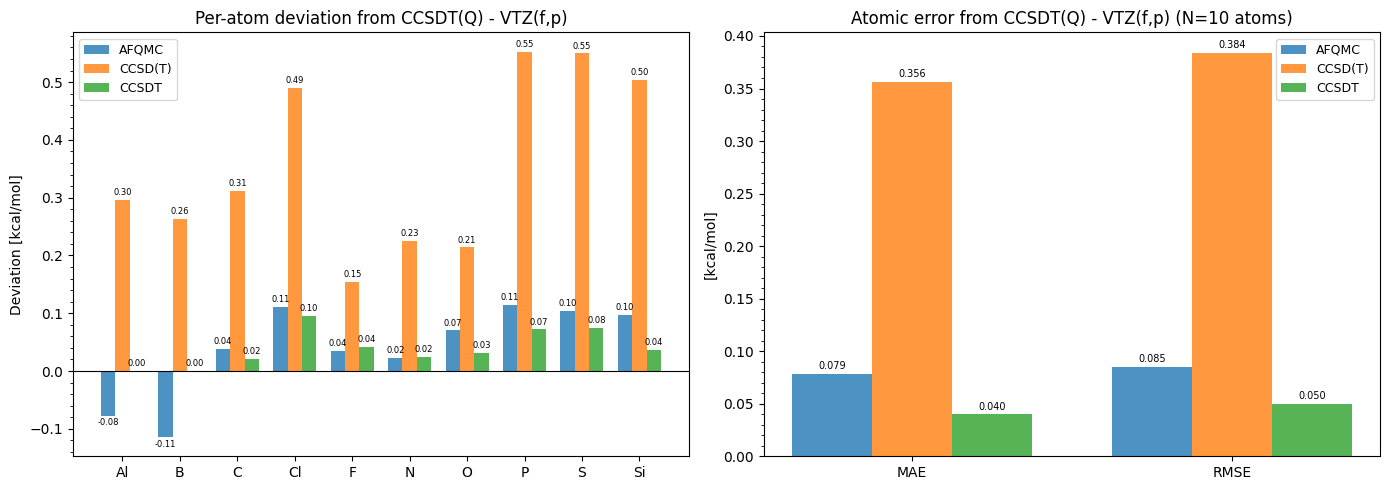

Saved atomic_energy_comparison_vtzfp.png

Atomic total-energy deviation from CCSDT(Q) -- 10 atoms
   AFQMC   MAE= 0.0786   RMSE= 0.0854 kcal/mol
 CCSD(T)   MAE= 0.3561   RMSE= 0.3843 kcal/mol
   CCSDT   MAE= 0.0398   RMSE= 0.0501 kcal/mol


In [13]:
# --- Atomic total-energy deviations from CCSDT(Q) ---
atom_names = sorted(a for a in atom_afqmc
                    if a != 'h' and np.isfinite(atom_ref[a]['CCSDT(Q)']))

# signed per-atom deviations from CCSDT(Q), in kcal/mol
adAFQMC  = np.array([atom_afqmc[a]          - atom_ref[a]['CCSDT(Q)'] for a in atom_names]) * HARTREE2KCAL
adCCSD_T = np.array([atom_ref[a]['CCSD(T)'] - atom_ref[a]['CCSDT(Q)'] for a in atom_names]) * HARTREE2KCAL
adCCSDT  = np.array([atom_ref[a]['CCSDT']   - atom_ref[a]['CCSDT(Q)'] for a in atom_names]) * HARTREE2KCAL
adeltas = [adAFQMC, adCCSD_T, adCCSDT]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: signed per-atom deviation, grouped bars per method
ax = axes[0]
w = 0.25
x_base = np.arange(len(atom_names))
for j, (mlabel, delta, mcolor) in enumerate(zip(method_labels, adeltas, method_colors)):
    bars = ax.bar(x_base + (j - 1) * w, delta, width=w, color=mcolor, alpha=0.8, label=mlabel)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)
ax.axhline(0.0, color='k', linewidth=0.8)
ax.set_xticks(x_base)
ax.set_xticklabels([a.capitalize() for a in atom_names])
ax.set_ylabel('Deviation [kcal/mol]')
ax.set_title('Per-atom deviation from CCSDT(Q) - VTZ(f,p)')
ax.legend(fontsize=9)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# right: MAE / RMSE aggregated over all atoms
ax = axes[1]
stat_labels = ['MAE', 'RMSE']
x_base = np.arange(len(stat_labels))
for j, (mlabel, delta, mcolor) in enumerate(zip(method_labels, adeltas, method_colors)):
    vals = [np.abs(delta).mean(), np.sqrt((delta**2).mean())]
    bars = ax.bar(x_base + (j - 1) * w, vals, width=w, color=mcolor, alpha=0.8, label=mlabel)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)
ax.set_xticks(x_base)
ax.set_xticklabels(stat_labels)
ax.set_ylabel('[kcal/mol]')
ax.set_title(f'Atomic error from CCSDT(Q) - VTZ(f,p) (N={len(atom_names)} atoms)')
ax.legend(fontsize=9)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig('atomic_energy_comparison_vtzfp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved atomic_energy_comparison_vtzfp.png')

print()
print(f'Atomic total-energy deviation from CCSDT(Q) -- {len(atom_names)} atoms')
print('=' * 70)
for mlabel, delta in zip(method_labels, adeltas):
    print(f'{mlabel:>8s}   MAE={np.abs(delta).mean():7.4f}   '
          f'RMSE={np.sqrt((delta**2).mean()):7.4f} kcal/mol')

## Why does CCSD(T) atomization accuracy jump from DZ to TZ?

In the atomization bar charts the **CCSD(T)** RMSD vs CCSDT(Q) drops sharply
from **1.20 kcal/mol (VDZ(d,s)) to 0.83 kcal/mol (VTZ(f,p))**, while the other
two methods barely move (**CCSDT 1.22 → 1.34**, **AFQMC 0.86 → 0.81**). The CC
energies themselves were verified against the reference CSVs, so this is real,
not a data error. The cell below decomposes the effect.

For each molecule's atomization energy (AE), the CCSD(T) deviation from the
CCSDT(Q) reference splits **exactly** into two physical pieces:

$$\underbrace{AE_{\rm CCSD(T)}-AE_{\rm CCSDT(Q)}}_{D[\mathrm{CCSD(T)}]}
=\underbrace{\big(AE_{\rm CCSD(T)}-AE_{\rm CCSDT}\big)}_{T_{\rm pert}\ \text{(approx-triples error)}}
-\underbrace{\big(AE_{\rm CCSDT(Q)}-AE_{\rm CCSDT}\big)}_{Q_{\rm corr}\ \text{(post-CCSDT / quadruples)}}$$

while the CCSDT deviation is simply $D[\mathrm{CCSDT}]=-Q_{\rm corr}$. So CCSD(T)
is accurate **only when its perturbative-triples error $T_{\rm pert}$ cancels the
neglected quadruples correction $Q_{\rm corr}$** — the well-known fortuitous
error cancellation behind CCSD(T)'s "gold standard" reputation.

In [14]:
# --- Decompose the CCSD(T) atomization deviation: T_pert vs Q_corr (DZ vs TZ) ---
def ae_cc_components(dat_path):
    '''Load CC energies from a combined energy_*.dat and return per-molecule
    atomization-energy components (kcal/mol) over molecules with a finite
    CCSDT(Q) reference, reusing the `compositions` built earlier.'''
    m_cc, a_cc = {}, {}
    for line in open(dat_path):
        if skip_line(line):
            continue
        p = line.split(); nm = p[0].lower()
        rec = {'CCSD(T)': to_float(p[3]), 'CCSDT': to_float(p[4]), 'CCSDT(Q)': to_float(p[5])}
        (a_cc if nm in ATOMS else m_cc)[nm] = rec
    names = [m for m in m_cc if m in compositions and np.isfinite(m_cc[m]['CCSDT(Q)'])]
    def AE(m, meth):
        return (sum(n * a_cc[e][meth] for e, n in compositions[m].items())
                - m_cc[m][meth]) * HARTREE2KCAL
    Tpert = np.array([AE(m, 'CCSD(T)')  - AE(m, 'CCSDT') for m in names])  # approx-triples error
    Qcorr = np.array([AE(m, 'CCSDT(Q)') - AE(m, 'CCSDT') for m in names])  # quadruples correction
    return names, Tpert, Qcorr

rms = lambda x: np.sqrt(np.mean(x**2))
print(f"{'basis':<10}{'N':>4}{'RMSD':>8}{'RMSD':>8}   |   "
      f"{'Tpert':>16}{'Qcorr':>16}{'corr':>7}{'cancel':>8}")
print(f"{'':<10}{'':>4}{'CCSD(T)':>8}{'CCSDT':>8}   |   "
      f"{'mean   RMS':>16}{'mean   RMS':>16}{'(T,Q)':>7}{'%':>8}")
print('-' * 86)
for path, label in [('../vdzds/energy_vdzds.dat', 'VDZ(d,s)'),
                    ('energy_vtzfp.dat', 'VTZ(f,p)')]:
    names, Tp, Qc = ae_cc_components(path)
    Dt   = Tp - Qc        # CCSD(T) deviation from CCSDT(Q)
    Dsdt = -Qc            # CCSDT  deviation from CCSDT(Q)
    cancel = 100 * (1 - rms(Dt) / rms(Qc))   # how much of Q_corr is cancelled by T_pert
    print(f"{label:<10}{len(names):>4}{rms(Dt):>8.3f}{rms(Dsdt):>8.3f}   |   "
          f"{Tp.mean():>7.3f}{rms(Tp):>7.3f}{Qc.mean():>8.3f}{rms(Qc):>8.3f}"
          f"{np.corrcoef(Tp, Qc)[0, 1]:>7.2f}{cancel:>7.0f}%")

basis        N    RMSD    RMSD   |              Tpert           Qcorr   corr  cancel
               CCSD(T)   CCSDT   |         mean   RMS      mean   RMS  (T,Q)       %
--------------------------------------------------------------------------------------
VDZ(d,s)   200   1.197   1.217   |     0.033  0.350   0.945   1.217   0.20      2%
VTZ(f,p)   198   0.827   1.343   |     0.576  0.812   1.024   1.343   0.60     38%


### Interpretation

The numbers above tell a consistent story:

- **$Q_{\rm corr}$ (the quadruples correction) is large and only grows slightly**
  with basis (mean ≈ +0.95 → +1.02 kcal/mol). This *is* the CCSDT error, so
  CCSDT's deviation stays large (even nudges up) from DZ to TZ.
- **$T_{\rm pert}$ (the perturbative-triples error) is what changes dramatically.**
  In the small **DZ** basis it is tiny (mean ≈ +0.03, RMS ≈ 0.35) and barely
  correlated with $Q_{\rm corr}$ (corr ≈ 0.20), so there is almost **no
  cancellation**: CCSD(T) carries essentially the full quadruples error and is
  no better than CCSDT (1.20 vs 1.22 kcal/mol).
- In the larger **TZ** basis $T_{\rm pert}$ grows by an order of magnitude
  (mean ≈ +0.58, RMS ≈ 0.81) and now **correlates strongly** with $Q_{\rm corr}$
  (corr ≈ 0.60), cancelling roughly **40 %** of it. That is exactly why CCSD(T)
  collapses to 0.83 kcal/mol while CCSDT does not improve.

**Reason, in one sentence:** CCSD(T)'s accuracy comes from the cancellation
between its overestimated perturbative triples and the neglected quadruples, and
that cancellation requires a sufficiently rich virtual space — the DZ(d,s) basis
is too small for the $(T)$ overshoot to develop, so the cancellation only
"switches on" at the TZ(f,p) level. CCSDT (no triples approximation, hence no
compensating term) and AFQMC (variationally-flavoured, no such basis-sensitive
cancellation) therefore show deviations from CCSDT(Q) that are nearly
basis-independent.